### Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv('../Data/train.csv')
test = pd.read_csv('../Data/test.csv')

In [3]:
train.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [4]:
test.head()

,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change
0,439140,D119,MEDIUM,British Grand Prix,2023,0,21,1,21.0,4,93.387,0.280,-4.984,0.403846,0.0
1,439141,VER,MEDIUM,Abu Dhabi Grand Prix,2023,0,24,1,24.0,1,90.867,-0.129,-1.990,0.413793,0.0
2,439142,D270,MEDIUM,British Grand Prix,2023,0,24,1,24.0,11,92.871,0.041,-8.842,0.461538,0.0
3,439143,D112,SOFT,São Paulo Grand Prix,2024,0,6,2,4.0,15,94.967,-19.741,8.250,0.077922,1.0
4,439144,AND,HARD,United States Grand Prix,2024,0,52,2,29.0,12,99.112,0.930,-20.848,0.722222,7.0


### Exploring Dataset

In [5]:
test.shape

(188165, 15)

In [6]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188165 entries, 0 to 188164
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      188165 non-null  int64  
 1   Driver                  188165 non-null  object 
 2   Compound                188165 non-null  object 
 3   Race                    188165 non-null  object 
 4   Year                    188165 non-null  int64  
 5   PitStop                 188165 non-null  int64  
 6   LapNumber               188165 non-null  int64  
 7   Stint                   188165 non-null  int64  
 8   TyreLife                188165 non-null  float64
 9   Position                188165 non-null  int64  
 10  LapTime (s)             188165 non-null  float64
 11  LapTime_Delta           188165 non-null  float64
 12  Cumulative_Degradation  188165 non-null  float64
 13  RaceProgress            188165 non-null  float64
 14  Position_Change     

In [7]:
train.shape

(439140, 16)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [9]:
train.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
PitNextLap                0
dtype: int64

In [10]:
test.isna().sum()

id                        0
Driver                    0
Compound                  0
Race                      0
Year                      0
PitStop                   0
LapNumber                 0
Stint                     0
TyreLife                  0
Position                  0
LapTime (s)               0
LapTime_Delta             0
Cumulative_Degradation    0
RaceProgress              0
Position_Change           0
dtype: int64

#### As there are no null values we'll move on to graph plotting

### Plotting Graphs

In [11]:
train.drop(['id'], inplace = True, axis = 1)

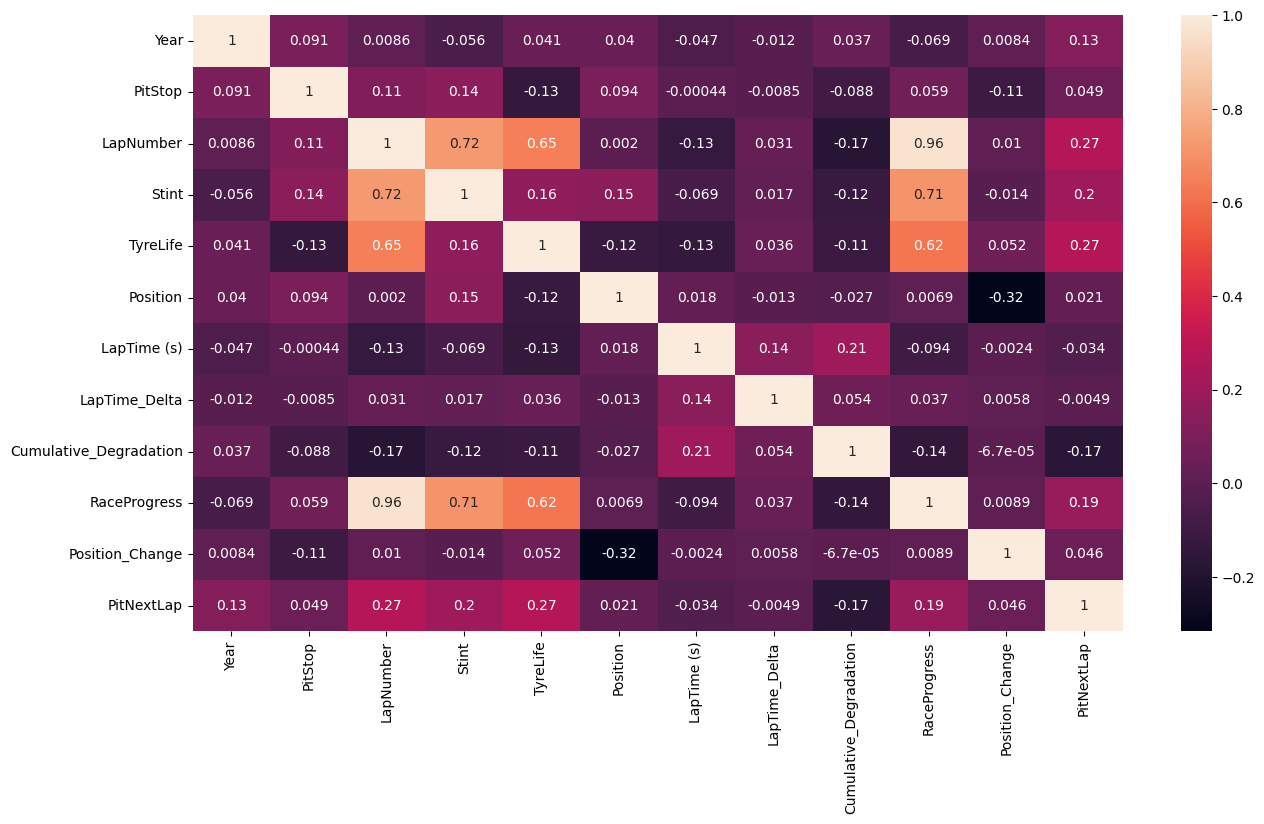

In [12]:
plt.figure(figsize = (15, 8))
sns.heatmap(train.corr(numeric_only = True), annot = True)
plt.show()

In [13]:
num_cols = train.select_dtypes(include = 'number').columns
num_cols = num_cols.drop(['PitNextLap'])

num_cols

Index(['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
       'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
       'RaceProgress', 'Position_Change'],
      dtype='object')

In [14]:
train.columns

Index(['Driver', 'Compound', 'Race', 'Year', 'PitStop', 'LapNumber', 'Stint',
       'TyreLife', 'Position', 'LapTime (s)', 'LapTime_Delta',
       'Cumulative_Degradation', 'RaceProgress', 'Position_Change',
       'PitNextLap'],
      dtype='object')

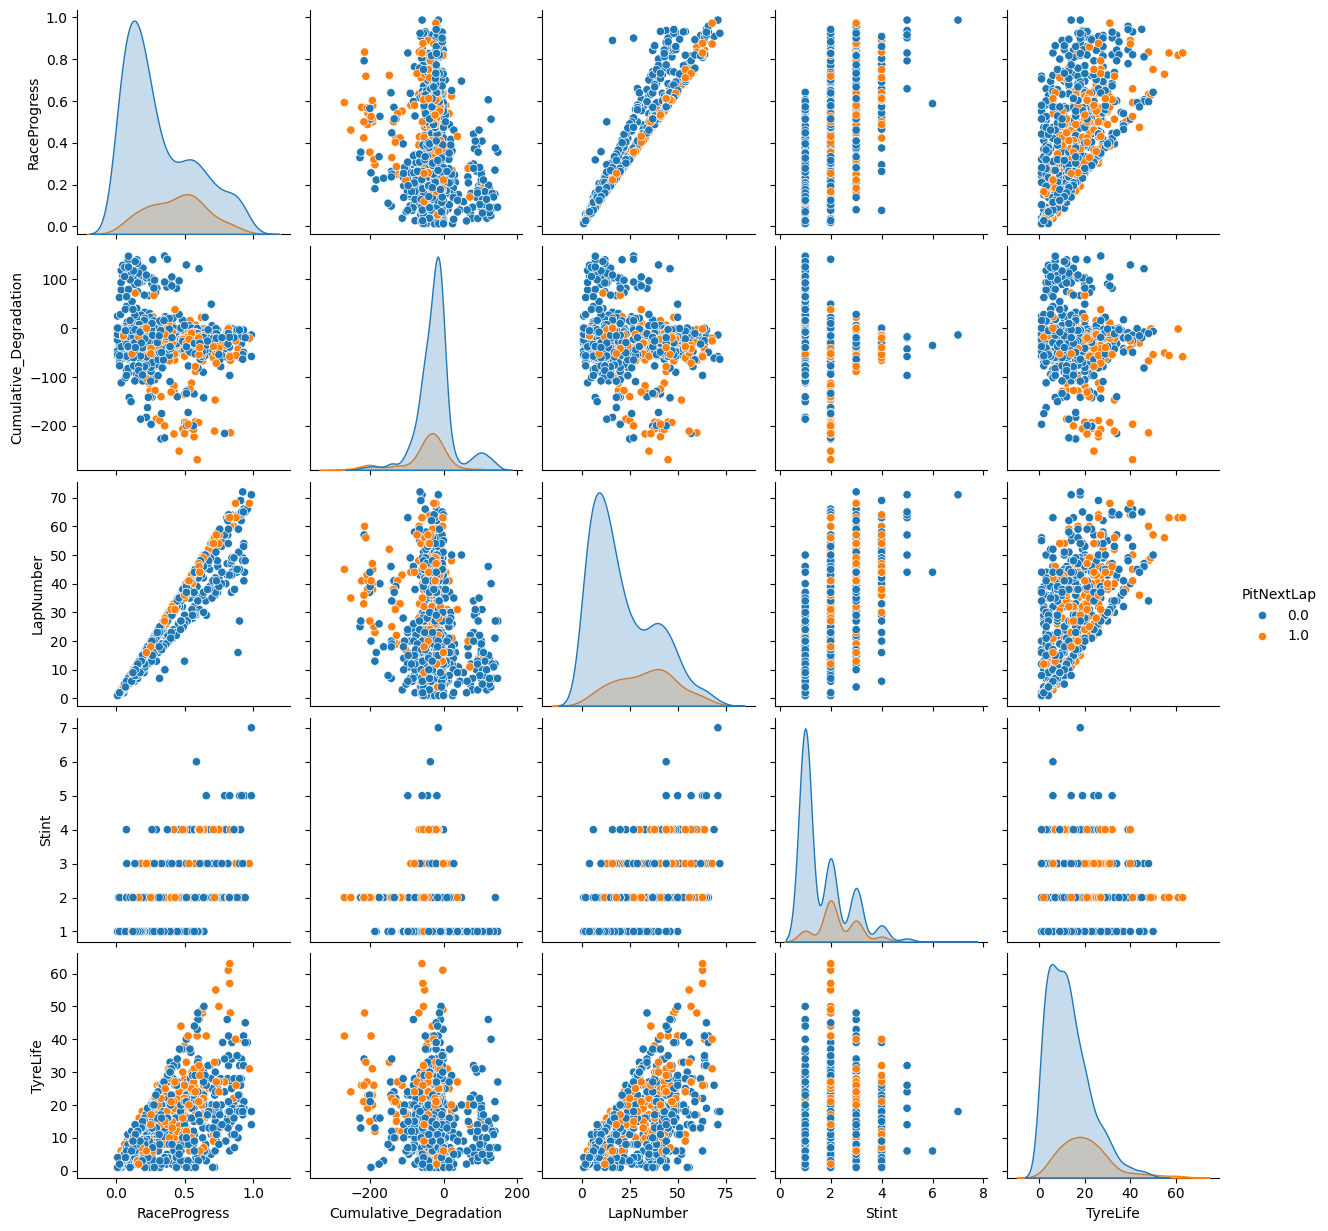

In [15]:
sns.pairplot(train[['RaceProgress', 'Cumulative_Degradation', 'LapNumber', 'Stint', 'TyreLife', 'PitNextLap']].sample(1000), hue = 'PitNextLap')
plt.show()

### Model Training

In [42]:
from sklearn.preprocessing import StandardScaler, TargetEncoder, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV 
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, auc, roc_curve

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [18]:
train.head()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [19]:
train.nunique()

Driver                       887
Compound                       5
Race                          26
Year                           4
PitStop                        2
LapNumber                     78
Stint                          8
TyreLife                      78
Position                      20
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
RaceProgress                1898
Position_Change               37
PitNextLap                     2
dtype: int64

#### Splitting Categorical and Numerical Features

In [20]:
data = train.drop(['PitNextLap'], axis = 1)

In [21]:
num_cols = train.select_dtypes(include = 'number')
cat_cols = train.select_dtypes(include = 'object')

In [22]:
cat_cols.columns
num_cols = num_cols.drop(['PitNextLap'], axis = 1)

In [23]:
cat_cols['Driver'].value_counts()

Driver
MAS     1682
RAI     1669
BAR     1656
BUT     1655
FIS     1651
        ... 
D723       1
D677       1
D731       1
D716       1
D714       1
Name: count, Length: 887, dtype: int64

In [24]:
cat_cols['Compound'].value_counts()

Compound
MEDIUM          211141
HARD            170518
SOFT             38744
INTERMEDIATE     17382
WET               1355
Name: count, dtype: int64

In [25]:
cat_cols['Race'].value_counts()

Race
Dutch Grand Prix             24462
Mexico City Grand Prix       23672
Pre-Season Testing           22492
Hungarian Grand Prix         22481
Monaco Grand Prix            21539
Canadian Grand Prix          21416
Austrian Grand Prix          21223
Spanish Grand Prix           20483
Italian Grand Prix           19854
Bahrain Grand Prix           19535
Singapore Grand Prix         18960
Miami Grand Prix             18860
Australian Grand Prix        18406
Saudi Arabian Grand Prix     18111
United States Grand Prix     18045
Abu Dhabi Grand Prix         16427
Emilia Romagna Grand Prix    15483
British Grand Prix           15383
Qatar Grand Prix             13817
Japanese Grand Prix          12891
Las Vegas Grand Prix         12479
Azerbaijan Grand Prix        12126
São Paulo Grand Prix         11497
Belgian Grand Prix            9002
Chinese Grand Prix            7311
French Grand Prix             3185
Name: count, dtype: int64

In [26]:
cat_cols = cat_cols.drop(['Race', 'Driver'], axis = 1)

In [28]:
num_pipeline = Pipeline(steps = [
    ('Scaling', StandardScaler())
])

In [29]:
cat_pipeline = Pipeline(steps = [
    ('Encoder', OneHotEncoder())
])

In [30]:
num_cols = list(num_cols)
cat_cols = list(cat_cols)

In [31]:
main_pipeline = ColumnTransformer(transformers = [
    ('Numerical', num_pipeline, num_cols),
    ('Categorical', cat_pipeline, cat_cols)],
    remainder = 'passthrough'
)

In [32]:
models = {
    'LogisticRegression': LogisticRegression(),
    'RandomForestClassifier': RandomForestClassifier(),
    'DecisonTreeClassifier': DecisionTreeClassifier(),
    'Catboost': CatBoostClassifier(verbose = False),
    'XGboost': XGBClassifier()
}

In [33]:
train.drop(['Driver', 'Race'], axis = 1, inplace = True)

In [34]:
X = train.drop(['PitNextLap'], axis = 1)
y = train['PitNextLap']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 7)

In [37]:
X_train_transformed = main_pipeline.fit_transform(X_train)
X_test_transformed = main_pipeline.transform(X_test)


Model: LogisticRegression
**************************************************
Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.85      0.90     78384
         1.0       0.34      0.63      0.45      9444

    accuracy                           0.83     87828
   macro avg       0.65      0.74      0.67     87828
weighted avg       0.89      0.83      0.85     87828



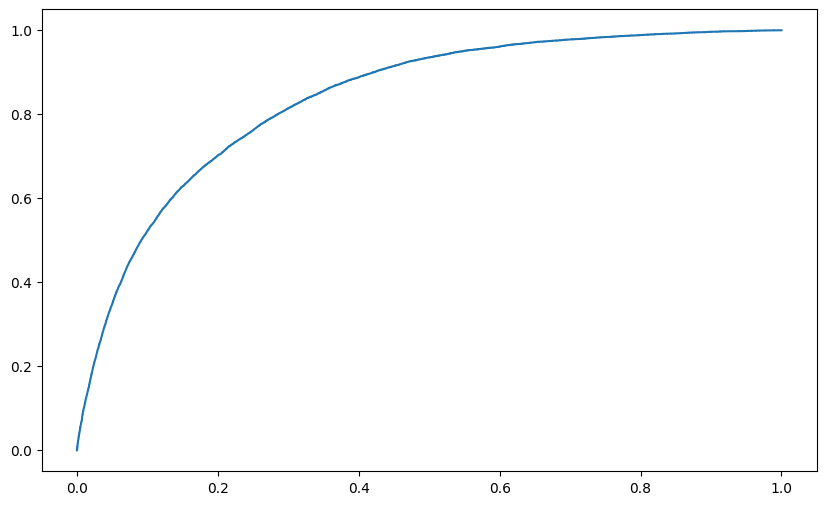

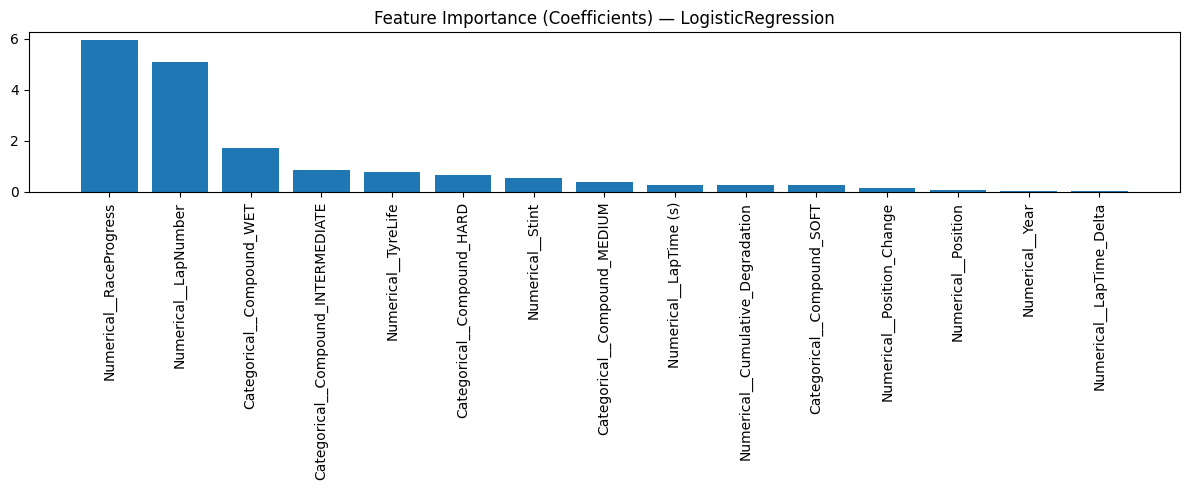

Model: RandomForestClassifier
**************************************************
Classification Report:
              precision    recall  f1-score   support

         0.0       0.94      0.92      0.93     71380
         1.0       0.69      0.73      0.71     16448

    accuracy                           0.89     87828
   macro avg       0.81      0.83      0.82     87828
weighted avg       0.89      0.89      0.89     87828



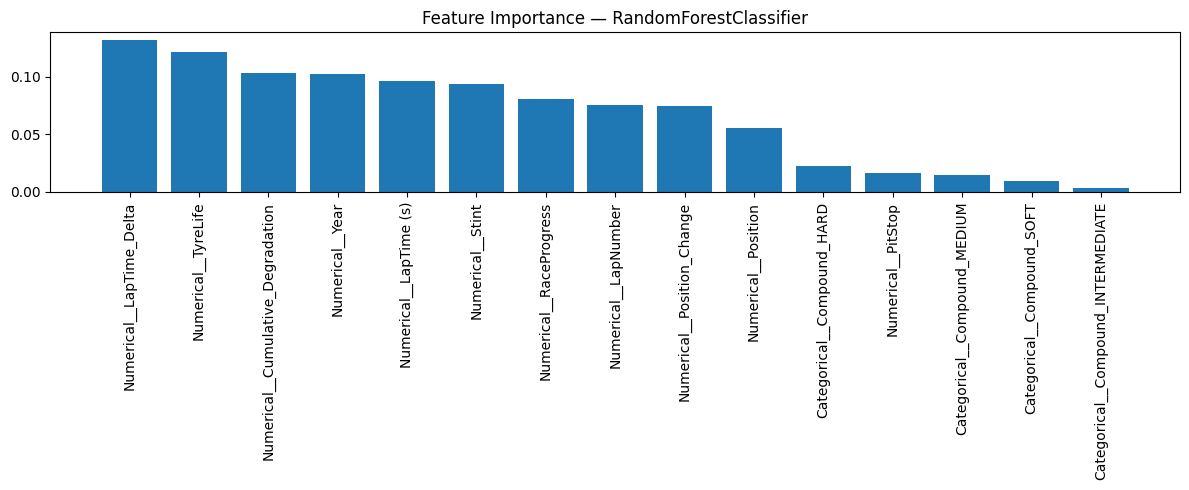

Model: DecisonTreeClassifier
**************************************************
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.91      0.90     70160
         1.0       0.62      0.61      0.61     17668

    accuracy                           0.85     87828
   macro avg       0.76      0.76      0.76     87828
weighted avg       0.84      0.85      0.84     87828



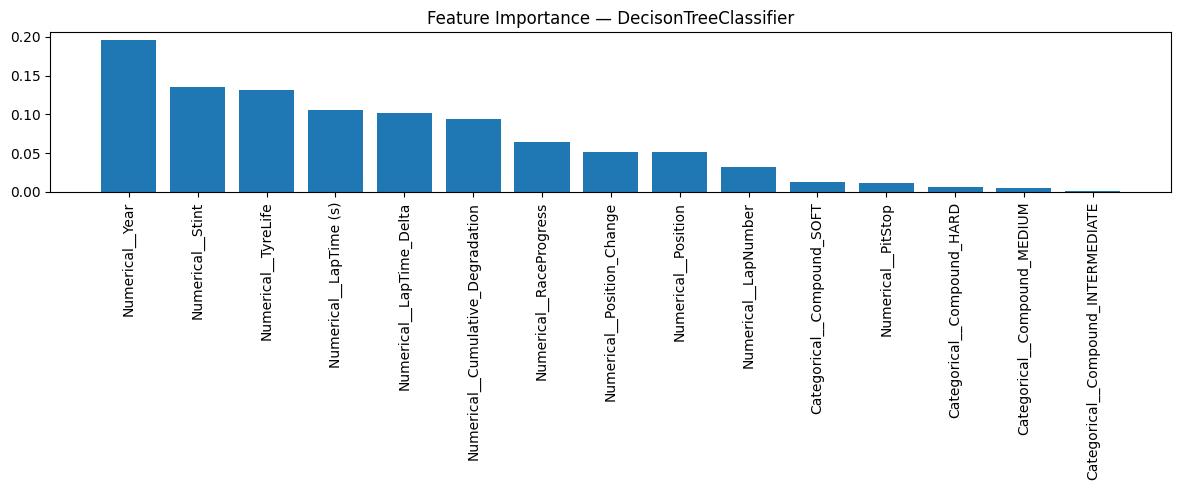

Model: Catboost
**************************************************
Classification Report:
              precision    recall  f1-score   support

         0.0       0.93      0.93      0.93     70675
         1.0       0.72      0.73      0.73     17153

    accuracy                           0.89     87828
   macro avg       0.83      0.83      0.83     87828
weighted avg       0.89      0.89      0.89     87828



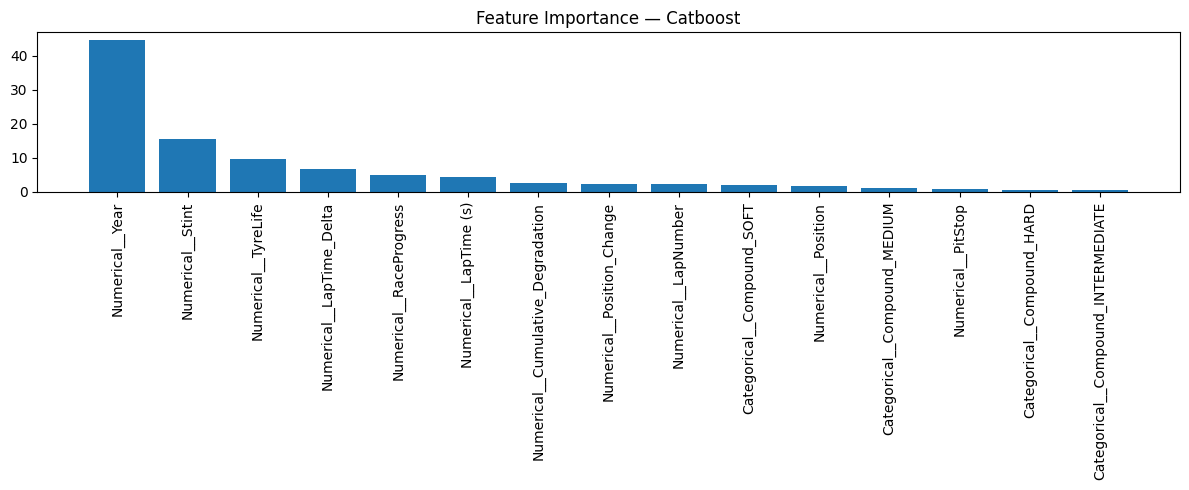

Model: XGboost
**************************************************
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93     70530
           1       0.72      0.73      0.73     17298

    accuracy                           0.89     87828
   macro avg       0.83      0.83      0.83     87828
weighted avg       0.89      0.89      0.89     87828



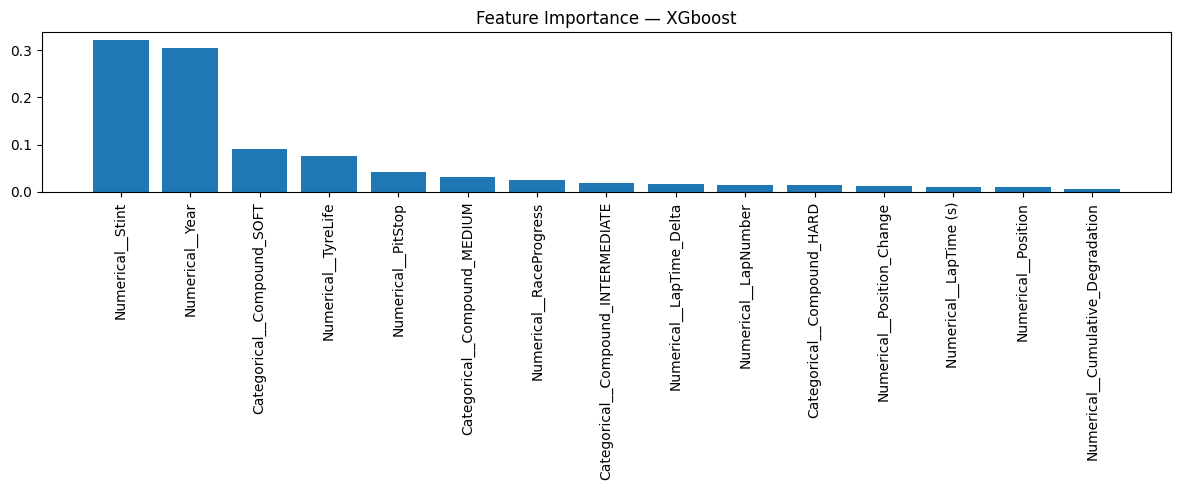

<Figure size 640x480 with 0 Axes>

In [ ]:
feature_names = main_pipeline.get_feature_names_out()

fig_roc, ax_roc = plt.subplots(figsize=(10, 6))

for name, model in models.items():
    model.fit(X_train_transformed, y_train)
    predict = model.predict(X_test_transformed)

    print(f'Model: {name}')
    print('*' * 50)
    print(f'Classification Report:\n{classification_report(predict, y_test)}')

    # ROC Curve
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_transformed)[:, 1]
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_test_transformed)
    else:
        print(f'{name} does not support ROC curve\n')
        continue

    fpr, tpr, _ = roc_curve(y_test, proba)
    roc_auc = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

    # Feature Importance
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        indices = np.argsort(importances)[::-1][:15]  # top 15

        plt.figure(figsize=(12, 5))
        plt.bar(range(15), importances[indices])
        plt.xticks(range(15), [feature_names[i] for i in indices], rotation=90)
        plt.title(f'Feature Importance — {name}')
        plt.tight_layout()
        plt.show()

    elif hasattr(model, 'coef_'):
        importances = np.abs(model.coef_[0])
        indices = np.argsort(importances)[::-1][:15]

        plt.figure(figsize=(12, 5))
        plt.bar(range(15), importances[indices])
        plt.xticks(range(15), [feature_names[i] for i in indices], rotation=90)
        plt.title(f'Feature Importance (Coefficients) — {name}')
        plt.tight_layout()
        plt.show()

    else:
        print(f'{name} does not support feature importance natively\n')

# Plot all ROC curves together
ax_roc.plot([0, 1], [0, 1], 'k--')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curves — All Models')
ax_roc.legend()
plt.tight_layout()
plt.show()

In [45]:
import joblib
from sklearn.metrics import roc_auc_score

best_model = None
best_score = 0
best_name = ''

for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        proba = model.predict_proba(X_test_transformed)[:, 1]
    elif hasattr(model, 'decision_function'):
        proba = model.decision_function(X_test_transformed)
    else:
        continue

    score = roc_auc_score(y_test, proba)
    if score > best_score:
        best_score = score
        best_model = model
        best_name = name

print(f'Best Model: {best_name} | AUC: {best_score:.4f}')

# save model
joblib.dump(best_model, 'best_model.pkl')

# submission
test_transformed = main_pipeline.transform(test)
predictions = best_model.predict(test_transformed)

submission = pd.DataFrame({
    'id': test['id'],
    'PitNextLap': predictions
})

submission.to_csv('submission.csv', index=False)
print(submission.head())

Best Model: Catboost | AUC: 0.9428
       id  PitNextLap
0  439140         0.0
1  439141         0.0
2  439142         0.0
3  439143         0.0
4  439144         1.0
